# VAR and DeepAR Fit

This notebook fits forecasting models to the simulated DGP datasets generated.

For now, this notebook only fits the classical VAR model. The DeepAR section is left as a stub and will be added later after the VAR/residual/innovation pipeline is validated.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.utils.seeds import set_seed
from src.experiments.config import ExperimentConfig
from src.experiments.paths import result_dirs
from src.experiments.artifacts import load_array_npz, save_array_npz, save_table, save_json, save_current_figure
from src.api.modeling import fit_model, fit_var_experiments
from src.vector_ar.stability import stability_summary
from src.vector_ar.forecast import forecast_var_mean

set_seed(123)

config = ExperimentConfig()
dgp_names = config.dgp_names
lags = config.lags
n_train = config.n_train
n_test = 100

dirs = result_dirs("02_var_deepar_fit",test=False,)
simulated_dir = ROOT / "data" / "simulated"
datasets = {}

for name in dgp_names:
    path = simulated_dir / f"{name}_var_dgp.npz"
    data = load_array_npz(path)
    y = data["y"]
    y_train = y[:n_train]
    y_test = y[n_train:n_train + n_test]
    datasets[name] = {
        "y": y,
        "y_train": y_train,
        "y_test": y_test,
        "innovations": data["innovations"],
        "A": data["A"],
        "Sigma": data["Sigma"],
    }

    print(
        name,
        "y:",y.shape,
        "train:",y_train.shape,
        "test:",y_test.shape,
    )

gaussian y: (400, 3) train: (300, 3) test: (100, 3)
student_t y: (400, 3) train: (300, 3) test: (100, 3)
mixture y: (400, 3) train: (300, 3) test: (100, 3)
heteroskedastic y: (400, 3) train: (300, 3) test: (100, 3)


## VAR Fitting

Each DGP is fitted using the same VAR specification. The goal is to keep the forecasting backbone fixed so that later differences in forecast calibration can be attributed primarily to innovation modeling choices.

In [2]:
var_fits, fit_summary_df = fit_var_experiments(
    datasets=datasets,
    lags=lags,
    output_dir=dirs["models"],
)

save_table(
    fit_summary_df,
    dirs["tables"] / "var_fit_summary.csv",
)

fit_summary_df

,dgp,model,lags,n_train,n_test,stable,max_modulus,resid_mean_abs,resid_avg_std
0,gaussian,VAR,1,300,100,True,0.487574,1.534756e-17,1.010497
1,student_t,VAR,1,300,100,True,0.436948,8.564931e-17,1.385660
2,mixture,VAR,1,300,100,True,0.401257,8.057471e-17,1.416159
3,heteroskedastic,VAR,1,300,100,True,0.421918,7.543823e-17,1.806943


In [3]:
from src.api.modeling import generate_var_mean_forecasts
horizon = config.horizon

mean_forecasts = generate_var_mean_forecasts(
    datasets=datasets,
    var_fits=var_fits,
    lags=lags,
    horizon=horizon,
    output_dir=dirs["models"],
)

for name, forecast in mean_forecasts.items():
    print(
        name,
        forecast.shape,
    )

gaussian (40, 3)
student_t (40, 3)
mixture (40, 3)
heteroskedastic (40, 3)


Saved: var_mean_forecasts.png


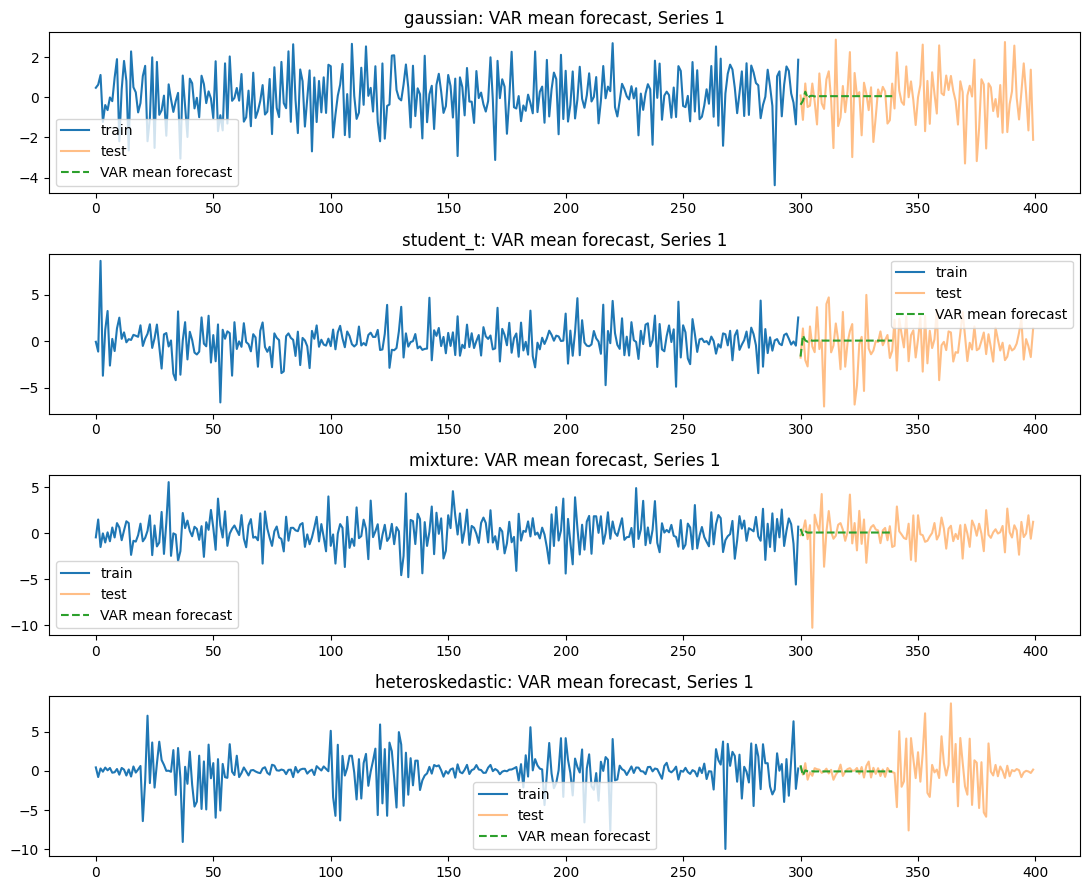

In [4]:
from src.plots.modeling import plot_mean_forecasts

plot_mean_forecasts(
    datasets=datasets,
    forecasts=mean_forecasts,
    dgp_names=dgp_names,
    horizon=horizon,
    forecast_label="VAR mean forecast",
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "var_mean_forecasts.png"
)

print(
    "Saved: var_mean_forecasts.png"
)

# Probabilistic "in the style of" DeepAR Forecaster

In [5]:
from src.utils.device import get_device
from src.api.modeling import fit_model

# RNN / DeepAR-style probabilistic forecaster configuration
rnn_context_length = 40
rnn_prediction_length = horizon
rnn_hidden_dim = 64
rnn_num_layers = 1
rnn_dropout = 0.0
rnn_batch_size = 32
rnn_epochs = 100
rnn_lr = 1e-3
rnn_device = get_device()

print("RNN device:", rnn_device)

RNN device: mps


In [7]:
from src.api.modeling import fit_rnn_experiments

rnn_fits, rnn_fit_summary_df = fit_rnn_experiments(
    datasets=datasets,
    output_dir=dirs["models"],
    context_length=rnn_context_length,
    prediction_length=rnn_prediction_length,
    hidden_dim=rnn_hidden_dim,
    num_layers=rnn_num_layers,
    dropout=rnn_dropout,
    batch_size=rnn_batch_size,
    epochs=rnn_epochs,
    lr=rnn_lr,
    device=rnn_device,
)

save_table(
    rnn_fit_summary_df,
    dirs["tables"] / "rnn_fit_summary.csv",
)

rnn_fit_summary_df


Fitting RNN for: gaussian
Epoch 0001 | loss = 1.901382
Epoch 0010 | loss = 1.540618
Epoch 0020 | loss = 1.533611
Epoch 0030 | loss = 1.526992
Epoch 0040 | loss = 1.520372
Epoch 0050 | loss = 1.511729
Epoch 0060 | loss = 1.498150
Epoch 0070 | loss = 1.475667
Epoch 0080 | loss = 1.444461
Epoch 0090 | loss = 1.404724
Epoch 0100 | loss = 1.361619

Fitting RNN for: student_t
Epoch 0001 | loss = 2.680038
Epoch 0010 | loss = 1.759141
Epoch 0020 | loss = 1.752149
Epoch 0030 | loss = 1.745487
Epoch 0040 | loss = 1.738263
Epoch 0050 | loss = 1.728858
Epoch 0060 | loss = 1.713851
Epoch 0070 | loss = 1.696713
Epoch 0080 | loss = 1.674881
Epoch 0090 | loss = 1.652979
Epoch 0100 | loss = 1.630691

Fitting RNN for: mixture
Epoch 0001 | loss = 3.178775
Epoch 0010 | loss = 1.881943
Epoch 0020 | loss = 1.874079
Epoch 0030 | loss = 1.867781
Epoch 0040 | loss = 1.858027
Epoch 0050 | loss = 1.849605
Epoch 0060 | loss = 1.838454
Epoch 0070 | loss = 1.824481
Epoch 0080 | loss = 1.806166
Epoch 0090 | loss = 

,dgp,model,context_length,prediction_length,hidden_dim,num_layers,epochs,final_loss
0,gaussian,RNN,40,40,64,1,100,1.361619
1,student_t,RNN,40,40,64,1,100,1.630691
2,mixture,RNN,40,40,64,1,100,1.759171
3,heteroskedastic,RNN,40,40,64,1,100,1.521256


In [8]:
from src.api.forecasts import generate_rnn_forecast_experiments

rnn_forecasts = generate_rnn_forecast_experiments(
    datasets=datasets,
    rnn_fits=rnn_fits,
    prediction_length=rnn_prediction_length,
    n_paths=config.n_paths,
    seed=config.seed,
    output_dir=dirs["forecasts"],
)


Generating RNN forecasts for: gaussian
gaussian (250, 40, 3) (40, 3)

Generating RNN forecasts for: student_t
student_t (250, 40, 3) (40, 3)

Generating RNN forecasts for: mixture
mixture (250, 40, 3) (40, 3)

Generating RNN forecasts for: heteroskedastic
heteroskedastic (250, 40, 3) (40, 3)


Saved: rnn_mean_forecasts.png


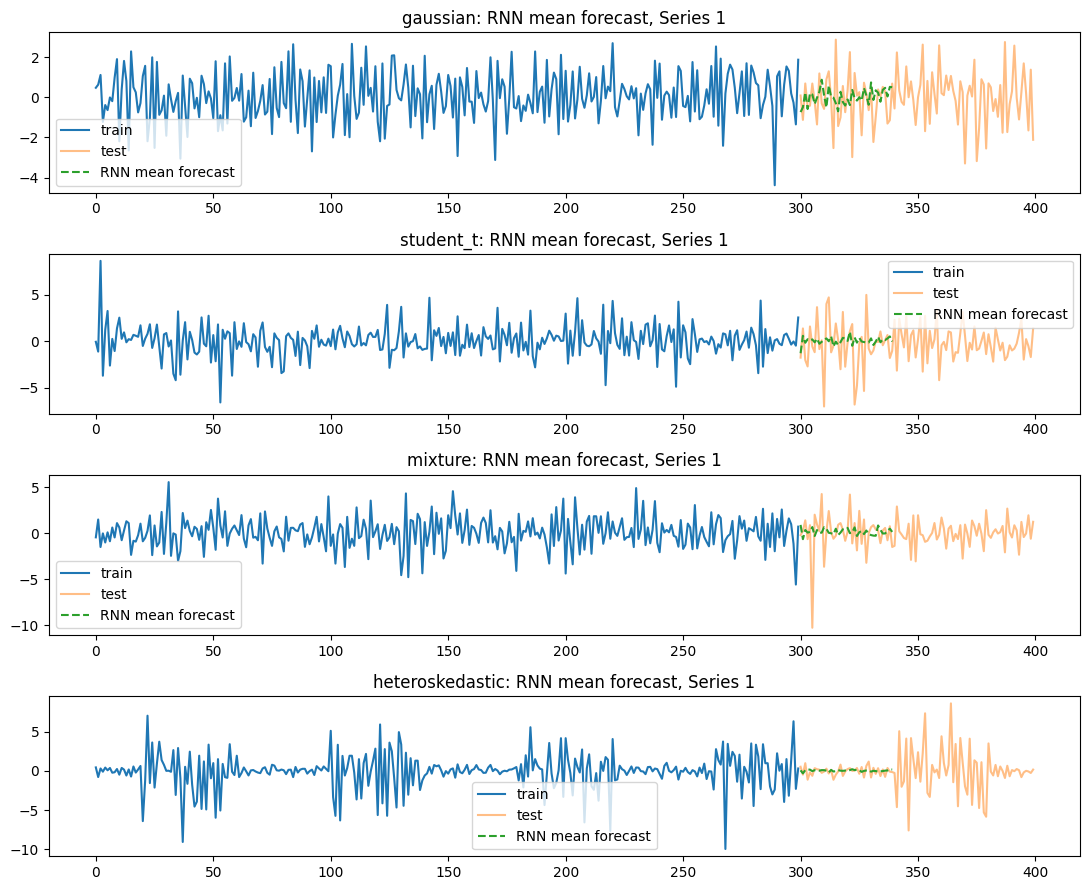

In [9]:
rnn_mean_forecasts = {
    name: forecast["predictive_mean"]
    for name, forecast in rnn_forecasts.items()
}

plot_mean_forecasts(
    datasets=datasets,
    forecasts=rnn_mean_forecasts,
    dgp_names=dgp_names,
    horizon=rnn_prediction_length,
    forecast_label="RNN mean forecast",
    variable=0,
)

save_current_figure(
    dirs["figures"] / "rnn_mean_forecasts.png"
)

print(
    "Saved: rnn_mean_forecasts.png"
)

Saved: rnn_training_loss.png


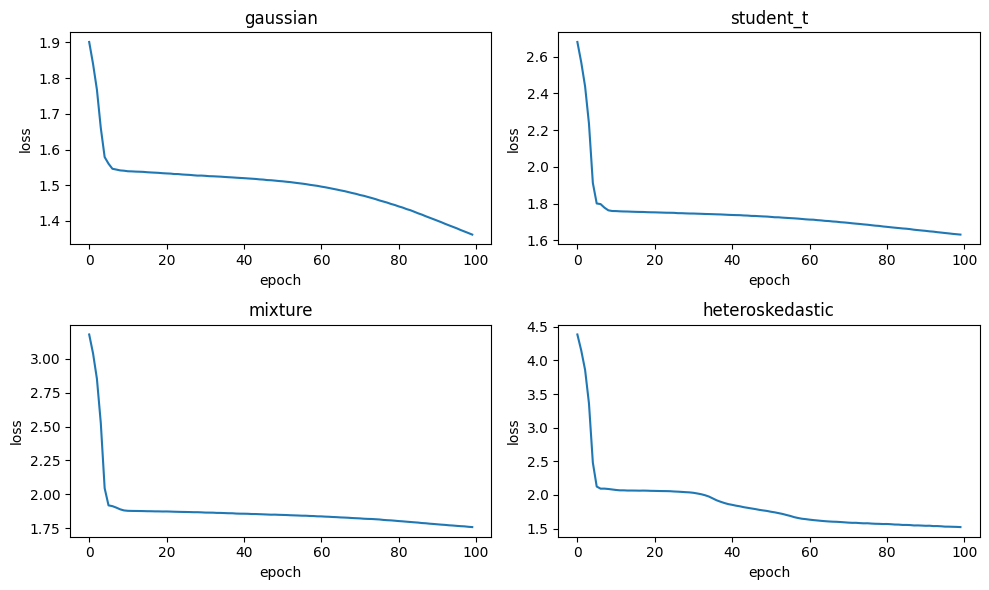

In [10]:
from src.plots.modeling import plot_rnn_training_loss
plot_rnn_training_loss(
    rnn_fits=rnn_fits,
    dgp_names=dgp_names,
)

save_current_figure(
    dirs["figures"] / "rnn_training_loss.png"
)

print(
    "Saved: rnn_training_loss.png"
)

In [11]:
for name in dgp_names:

    forecast = rnn_forecasts[name]

    scale = forecast["predictive_scale"]

    print(
        name,
        "mean scale:",
        scale.mean(),
        "max scale:",
        scale.max(),
    )

gaussian mean scale: 1.0304431 max scale: 1.6321676
student_t mean scale: 1.0547043 max scale: 1.6215657
mixture mean scale: 1.5470256 max scale: 2.5274665
heteroskedastic mean scale: 0.5758373 max scale: 1.3313231


In [12]:
from src.api.modeling import compare_mean_forecasts
mean_forecast_comparison_df = compare_mean_forecasts(
    datasets=datasets,
    mean_forecasts=mean_forecasts,
    rnn_forecasts=rnn_forecasts,
    horizon=horizon,
)

save_table(
    mean_forecast_comparison_df,
    dirs["tables"] / "var_rnn_mean_forecast_comparison.csv",
)

mean_forecast_comparison_df

,dgp,var_mean_mse,rnn_mean_mse,var_mean_mae,rnn_mean_mae
0,gaussian,1.327511,1.414383,0.900841,0.911736
1,student_t,8.684729,8.891986,1.841044,1.866693
2,mixture,3.748972,3.981589,1.345518,1.411935
3,heteroskedastic,0.233268,0.231776,0.379008,0.387870


In [13]:
save_json(
    {
        "notebook": "02_var_deepar_fit",
        "models_fit": ["VAR", "Probabilistic RNN"],
        "dgp_names": dgp_names,
        "lags": lags,
        "n_train": n_train,
        "n_test": n_test,
        "horizon": horizon,
        "all_var_stable": bool(fit_summary_df["stable"].all()),
        "rnn_context_length": rnn_context_length,
        "rnn_prediction_length": rnn_prediction_length,
        "rnn_hidden_dim": rnn_hidden_dim,
        "rnn_num_layers": rnn_num_layers,
        "rnn_epochs": rnn_epochs,
        "rnn_lr": rnn_lr,
        "rnn_device": str(rnn_device),
    },
    dirs["logs"] / "fit_metadata.json",
)

print("02_var_deepar_fit completed.")

02_var_deepar_fit completed.
